In [ ]:
import yfinance as yf 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import random

from sklearn.decomposition import PCA 
from sklearn.preprocessing import StandardScaler  

from hmmlearn import hmm

In [1]:
seed = 123 
random.seed(seed)

NameError: name 'random' is not defined

In [3]:
tickers = ["XLK","XLV","XLF","XLY","XLC","XLI","XLP","XLE","XLU","XLRE","XLB","^VIX", "^SPX"]

sector_data = yf.download(tickers, start="2019-01-01", auto_adjust = False)["Adj Close"]

sector_data.head()

[*********************100%***********************]  13 of 13 completed


Ticker,XLB,XLC,XLE,XLF,XLI,XLK,XLP,XLRE,XLU,XLV,XLY,^SPX,^VIX
Date,,,,,,,,,,,,,
2019-01-02,22.028011,39.142067,21.261763,21.041231,57.592129,29.068298,41.901955,23.986849,20.903225,75.582741,46.748024,2510.030029,23.219999
2019-01-03,21.403351,38.487053,21.050894,20.568197,55.839634,27.601294,41.661228,24.097715,20.899206,74.047997,45.735832,2447.889893,25.450001
2019-01-04,22.244909,40.143311,21.767132,21.251467,57.956863,28.824583,42.549412,24.343204,21.208677,76.256935,47.249432,2531.939941,21.379999
2019-01-07,22.322989,40.601814,22.090710,21.277748,58.428341,29.082355,42.491295,24.549107,21.063993,76.549683,48.317837,2549.689941,21.400000
2019-01-08,22.557241,41.284920,22.261593,21.295265,59.228962,29.326080,42.881432,24.976734,21.325232,77.144089,48.852051,2574.409912,20.469999


In [4]:
returns = sector_data.pct_change().dropna()
returns.head(10)

Ticker,XLB,XLC,XLE,XLF,XLI,XLK,XLP,XLRE,XLU,XLV,XLY,^SPX,^VIX
Date,,,,,,,,,,,,,
2019-01-03,-0.028358,-0.016734,-0.009918,-0.022481,-0.030429,-0.050468,-0.005745,0.004622,-0.000192,-0.020305,-0.021652,-0.024757,0.096038
2019-01-04,0.039319,0.043034,0.034024,0.033220,0.037916,0.044320,0.021319,0.010187,0.014808,0.029831,0.033094,0.034336,-0.159921
2019-01-07,0.003510,0.011422,0.014865,0.001237,0.008135,0.008943,-0.001366,0.008458,-0.006822,0.003839,0.022612,0.007010,0.000935
2019-01-08,0.010494,0.016825,0.007736,0.000823,0.013703,0.008381,0.009182,0.017419,0.012402,0.007765,0.011056,0.009695,-0.043458
2019-01-09,0.000384,0.001360,0.015842,0.004936,0.006759,0.012946,-0.009292,-0.004122,-0.006031,0.004485,0.005084,0.004098,-0.023937
2019-01-10,0.008843,0.002037,0.002894,0.000410,0.013576,0.004418,0.005862,0.015919,0.013083,0.001946,-0.002863,0.004518,-0.024024
2019-01-11,-0.004002,-0.004970,-0.005931,0.002455,-0.001031,-0.001885,0.002914,0.001880,-0.003743,0.003313,0.000957,-0.000146,-0.067179
2019-01-14,-0.007652,-0.003632,-0.002419,0.006939,-0.000147,-0.009286,-0.004842,-0.003128,-0.022544,-0.011047,-0.006120,-0.005258,0.048378
2019-01-15,-0.006555,0.016632,0.003557,0.008918,-0.003094,0.015091,0.009926,0.011296,0.012301,0.017964,0.009043,0.010722,-0.024646


In [5]:
sector_corr = returns.corr()

Text(0.5, 1.0, 'Correlations Matrix for the Sector Returns')

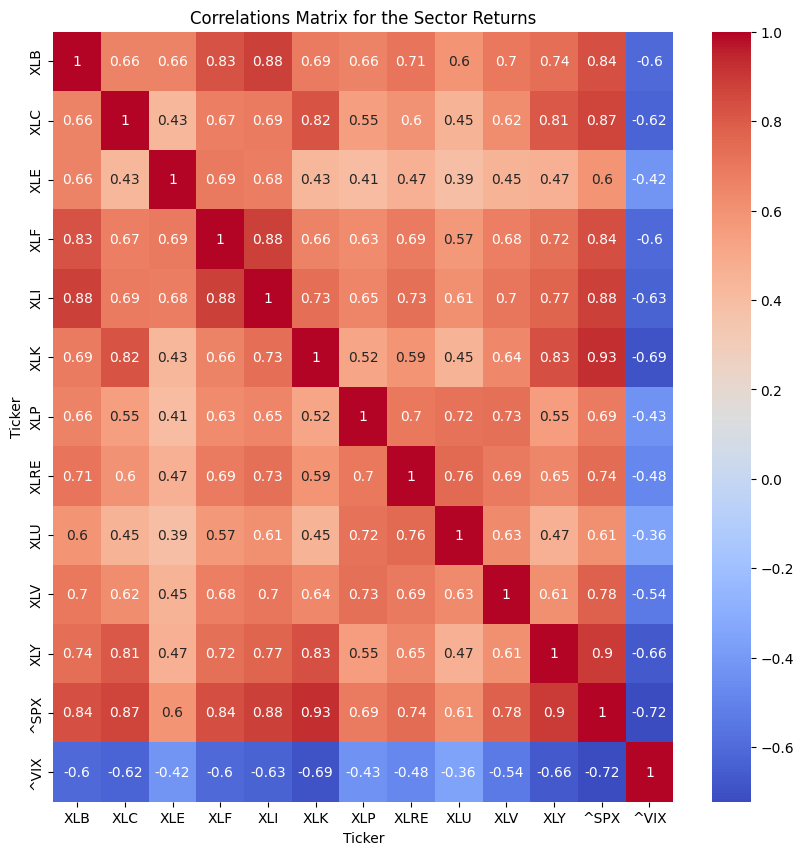

In [6]:
plt.figure(figsize=(10,10))
sns.heatmap(sector_corr, cmap="coolwarm", annot=True)
plt.title("Correlations Matrix for the Sector Returns")

OK so an option is to do training on a given ste of the data building out the hmm model then when we can evaluate the hmm on a test set time series of the data to get the log liklihood on the test set 

Would need to transform the test data using the PCA results of the training data 

In [11]:
scaler = StandardScaler()

returns_scaled = pd.DataFrame(
    scaler.fit_transform(returns), 
    columns = returns.columns 
)
returns_scaled.head()

Ticker,XLB,XLC,XLE,XLF,XLI,XLK,XLP,XLRE,XLU,XLV,XLY,^SPX,^VIX
0,-2.052773,-1.237226,-0.520198,-1.527659,-2.288657,-3.071049,-0.620686,0.299504,-0.052906,-1.884010,-1.454788,-2.037828,1.107747
1,2.758540,3.008986,1.616664,2.161907,2.742305,2.586096,2.106358,0.693437,1.084026,2.673279,2.127968,2.710612,-1.949828
2,0.212778,0.763096,0.684991,0.043390,0.550089,0.474700,-0.179436,0.571055,-0.555402,0.310656,1.441973,0.514858,-0.028304
3,0.709277,1.146937,0.338268,0.016005,0.959926,0.441141,0.883346,1.205352,0.901687,0.667520,0.685733,0.730602,-0.558608
4,-0.009441,0.048247,0.732470,0.288448,0.448809,0.713598,-0.978050,-0.319424,-0.495434,0.369346,0.294882,0.280830,-0.325425


In [12]:
pca = PCA(random_state=seed)
pca.fit_transform(returns_scaled)

array([[-5.06494844e+00,  1.81778021e+00,  1.70201598e-02, ...,
         5.56237268e-01, -1.29515725e-01,  2.61479754e-01],
       [ 7.93087971e+00, -1.07133670e+00, -1.69365364e-02, ...,
         2.05548211e-02,  3.06507111e-01, -7.57601121e-02],
       [ 1.40004508e+00, -9.64350327e-01,  1.87679222e-01, ...,
         5.27350721e-01,  3.41505903e-01, -5.17958221e-02],
       ...,
       [-4.15198558e+00, -4.32626873e-01,  1.07945122e+00, ...,
        -3.63184838e-01,  3.35089023e-01,  6.18260773e-03],
       [-9.85318443e-01, -6.12249656e-01,  6.22956217e-01, ...,
        -3.35200105e-01, -1.10018265e-01, -1.04322226e-01],
       [-4.15399021e+00, -1.26900217e+00,  1.44939529e+00, ...,
        -1.99460286e-01, -2.10199472e-01, -1.85954365e-02]],
      shape=(1813, 13))

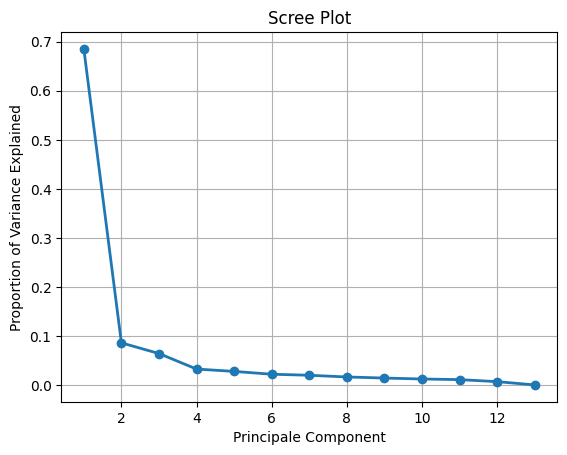

In [13]:
pc_explained_var = pca.explained_variance_ratio_
PC_vals = np.arange(len(pca.explained_variance_ratio_)) + 1

plt.plot(PC_vals, pc_explained_var, 'o-', linewidth=2)
plt.title("Scree Plot")
plt.xlabel("Principale Component")
plt.ylabel("Proportion of Variance Explained")
plt.grid(True)
plt.show()

From the elbow it looks like taking 3 or 4 PC's might be a good move to capture a significant portion of the variance. This is something that can be tuned

Refit using just 3 PC's

In [14]:
pca = PCA(n_components=3, random_state=seed)

latent_variables = pca.fit_transform(returns_scaled)
latent_variables.shape

(1813, 3)

In [15]:
Saved_PC = ["PC1", 'PC2', "PC3"]
df_loadings = pd.DataFrame(
    pca.components_, 
    columns = returns.columns, 
    index = Saved_PC 
)
df_loadings.head()

Ticker,XLB,XLC,XLE,XLF,XLI,XLK,XLP,XLRE,XLU,XLV,XLY,^SPX,^VIX
PC1,0.300024,0.276773,0.219635,0.297097,0.308807,0.283365,0.256223,0.274671,0.235783,0.274577,0.289203,0.326635,-0.242507
PC2,0.042830,-0.288102,0.037387,0.014329,0.008221,-0.340089,0.398285,0.311750,0.527202,0.192149,-0.283769,-0.149966,0.352328
PC3,0.224510,-0.228138,0.743760,0.295034,0.225494,-0.225773,-0.214331,-0.130391,-0.182588,-0.178258,-0.134813,-0.075935,0.059233


In PC1 -> Vix lower and S&P increased


In PC2/3 -> Vix higher and S&P lower 

In [ ]:
hmm_model = hmm.GaussianHMM(n_components=2, random_state=seed)
hmm_model.fit(latent_variables)

,n_components,2
,covariance_type,'diag'
,min_covar,0.001
,startprob_prior,1.0
,transmat_prior,1.0
,means_prior,0
,means_weight,0
,covars_prior,0.01
,covars_weight,1
,algorithm,'viterbi'
,random_state,None


In [26]:
probs = pd.Series(hmm_model.predict(latent_variables), index = returns.index)

# Number of days that we are each in regime
probs.value_counts()

0    1519
1     294
Name: count, dtype: int64

In [18]:
# Transition matrix -> Likely hood of transitioning between states 
transition_matrix = hmm_model.transmat_

In [19]:
#State Means
df_means = pd.DataFrame(
    hmm_model.means_,
    columns = Saved_PC,
)
df_means

,PC1,PC2,PC3
0,0.164220,-0.056303,-0.019544
1,-0.675764,0.231687,0.080423


So this result shows the PC1 contributes positively to the first regime (Low Vix and High SPY) which likely indicates this is the bullish region. 

Next we can look at the regiem classification using the outputs of the HMM on the actual time series data 

Text(0, 0.5, 'Daily % Returns')

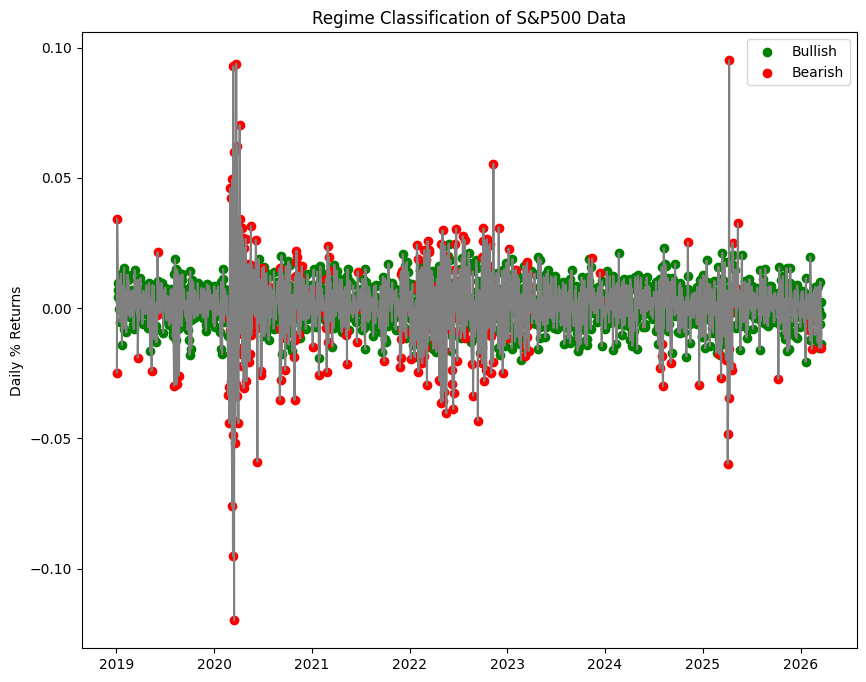

In [32]:
plt.figure(figsize=(10,8))
plt.plot(returns['^SPX'], color='gray')
plt.scatter(returns.index[probs == 0], returns['^SPX'][probs == 0], color='green', label = 'Bullish')
plt.scatter(returns.index[probs == 1], returns['^SPX'][probs == 1], color='red', label = 'Bearish')
plt.title("Regime Classification of S&P500 Data")
plt.legend()
plt.ylabel("Daily % Returns")


In [ ]:
#Build the 3 month returns data
spy_3m_return = ((1 + returns['^SPX']).rolling(60).apply(np.prod, raw= True) - 1).dropna()
spy_3m_return

Date
2019-03-29    0.129229
2019-04-01    0.171290
2019-04-02    0.132428
2019-04-03    0.126961
2019-04-04    0.118466
                ...   
2026-03-16   -0.014835
2026-03-17   -0.000795
2026-03-18   -0.022150
2026-03-19   -0.033362
2026-03-20   -0.054083
Name: ^SPX, Length: 1754, dtype: float64

In [41]:
matched_prediction = probs[len(returns) - len(spy_3m_return):]

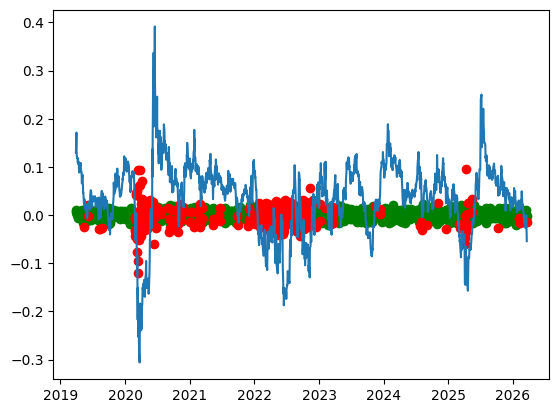

In [44]:
plt.plot(spy_3m_return)
plt.scatter(returns.index[len(returns) - len(spy_3m_return):][matched_prediction == 0], returns['^SPX'][len(returns) - len(spy_3m_return):][matched_prediction  == 0], color='green', label = 'Bullish')
plt.scatter(returns.index[len(returns) - len(spy_3m_return):][matched_prediction  == 1], returns['^SPX'][len(returns) - len(spy_3m_return):][matched_prediction == 1], color='red', label = 'Bearish')

Can do the pipeline once I know how many principale components to look at
- Also don't know how I can accerss the different things I need in the hmm library 

In [20]:
pca_pipeline = Pipeline([
    ('scaler', StandardScaler()), 
    ('pca', PCA())
]) 